# HR Employee Attrition Analytics — Exploratory Data Analysis

**Goal:** Identify the key factors driving employee attrition and surface actionable
retention insights for HR leadership.

**Stack:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** 1,470 employees · IBM HR Analytics schema (synthetic data, same structure
as the well-known public dataset)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('../data/hr_attrition_clean.csv')
df.head()

,EmployeeNumber,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag,TenureBand,IncomeBand,JobSatisfactionLabel,WorkLifeBalanceLabel
0,1,52,No,Travel_Rarely,503,Human Resources,9,1,Life Sciences,3,...,3,6.00,4,0,5,0,4-6 yrs,6K-10K,Very High,Better
1,2,44,No,Travel_Rarely,301,Research & Development,24,3,Technical Degree,4,...,1,11.00,5,2,4,0,10+ yrs,6K-10K,Very High,Bad
2,3,33,No,Travel_Frequently,845,Research & Development,15,3,Life Sciences,2,...,4,3.00,0,1,1,0,2-3 yrs,3K-6K,Low,Best
3,4,38,Yes,Travel_Frequently,1071,Sales,3,2,Life Sciences,4,...,3,6.00,0,1,3,1,4-6 yrs,6K-10K,Medium,Better
4,5,28,No,Travel_Rarely,1353,Research & Development,2,4,Life Sciences,1,...,3,6.00,3,4,6,0,4-6 yrs,3K-6K,Very High,Better


## 1. Data Overview

In [2]:
print(f"Shape: {df.shape}")
df.info()

Shape: (1470, 37)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeNumber            1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1470 non-null   str    
 3   BusinessTravel            1470 non-null   str    
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   str    
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   str    
 9   EnvironmentSatisfaction   1470 non-null   int64  
 10  Gender                    1470 non-null   str    
 11  HourlyRate                1470 non-null   int64  
 12  JobInvolvement            1470 non-null   int64  
 13  JobLevel                  1470 non-null   int64  
 14  J

In [3]:
print("Nulls per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() > 0 else "None")
print("\nDuplicate rows:", df.duplicated().sum())
print(f"\nOverall attrition rate: {(df['Attrition']=='Yes').mean()*100:.2f}%")

Nulls per column:
None

Duplicate rows: 0

Overall attrition rate: 26.19%


## 2. Attrition Overview

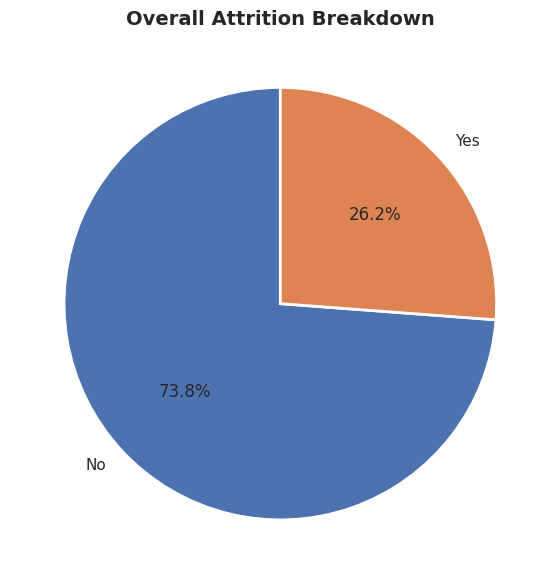

Attrition
No     1085
Yes     385
Name: count, dtype: int64

In [4]:
attr_counts = df['Attrition'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#4C72B0', '#DD8452']
ax.pie(attr_counts.values, labels=attr_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Overall Attrition Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/attrition_overview.png', dpi=120)
plt.show()

attr_counts

## 3. Attrition by Department

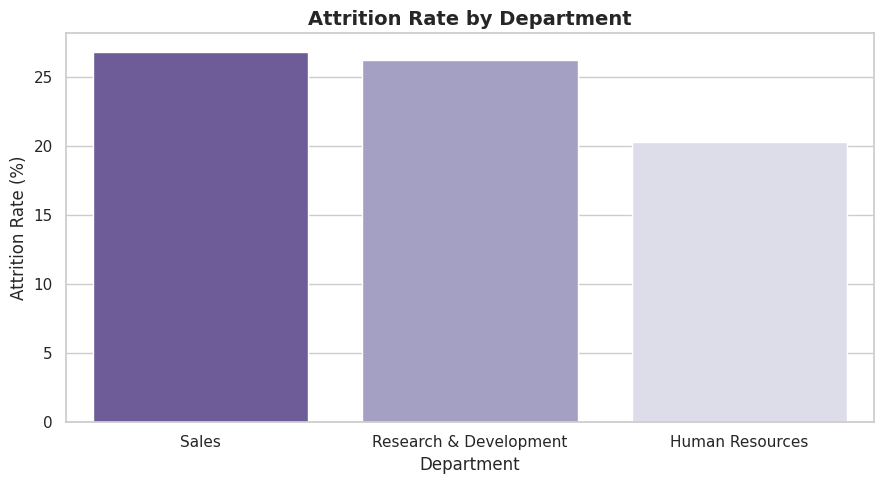

Department
Sales                    26.84
Research & Development   26.24
Human Resources          20.34
Name: Attrition, dtype: float64

In [5]:
dept_attr = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=dept_attr.index, y=dept_attr.values, ax=ax, palette='Purples_r', hue=dept_attr.index, legend=False)
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('../images/attrition_by_department.png', dpi=120)
plt.show()

dept_attr

## 4. The #1 Driver: OverTime

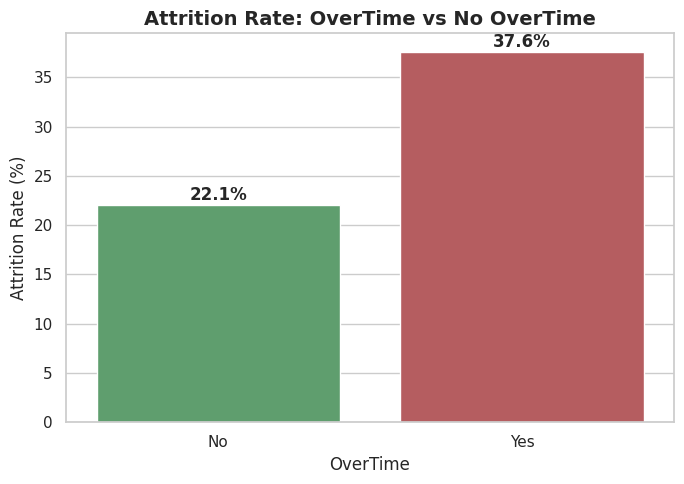

OverTime
No    22.06
Yes   37.60
Name: Attrition, dtype: float64

In [6]:
ot_attr = df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=ot_attr.index, y=ot_attr.values, ax=ax, palette=['#55A868','#C44E52'], hue=ot_attr.index, legend=False)
ax.set_title('Attrition Rate: OverTime vs No OverTime', fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
for i, v in enumerate(ot_attr.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/attrition_by_overtime.png', dpi=120)
plt.show()

ot_attr

**Insight:** Employees who work overtime attrite at nearly **2x the rate** of those who don't — the single strongest signal in this dataset. This is the first place HR should look when designing a retention intervention.

## 5. Job Satisfaction & Work-Life Balance

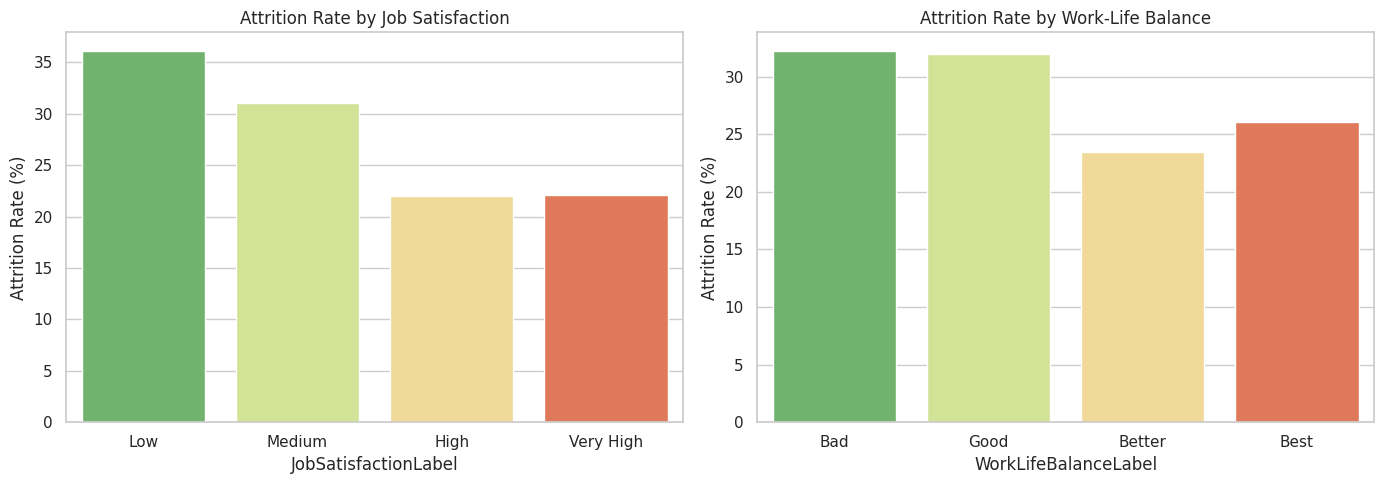

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sat_order = ['Low', 'Medium', 'High', 'Very High']
sat_attr = df.groupby('JobSatisfactionLabel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reindex(sat_order)
sns.barplot(x=sat_attr.index, y=sat_attr.values, ax=axes[0], palette='RdYlGn_r', hue=sat_attr.index, legend=False)
axes[0].set_title('Attrition Rate by Job Satisfaction')
axes[0].set_ylabel('Attrition Rate (%)')

wlb_order = ['Bad', 'Good', 'Better', 'Best']
wlb_attr = df.groupby('WorkLifeBalanceLabel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reindex(wlb_order)
sns.barplot(x=wlb_attr.index, y=wlb_attr.values, ax=axes[1], palette='RdYlGn_r', hue=wlb_attr.index, legend=False)
axes[1].set_title('Attrition Rate by Work-Life Balance')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('../images/satisfaction_worklife.png', dpi=120)
plt.show()

## 6. Tenure: The Early-Career Flight Risk

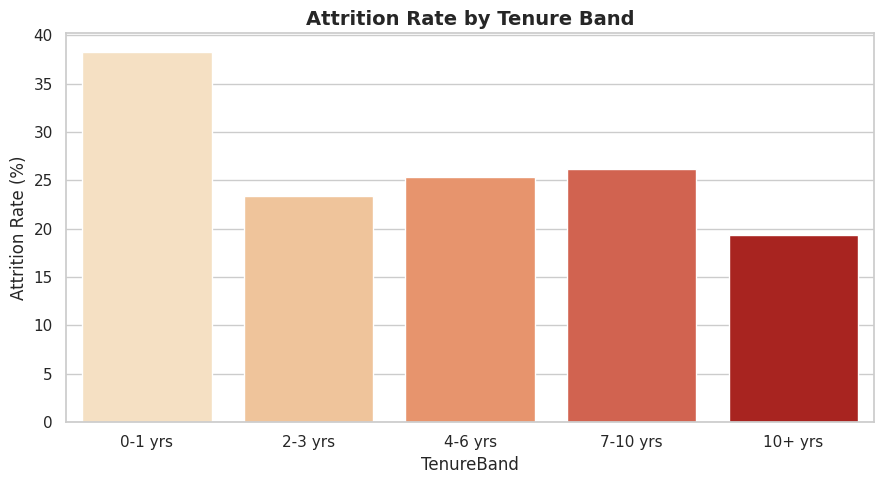

TenureBand
0-1 yrs    38.28
2-3 yrs    23.33
4-6 yrs    25.33
7-10 yrs   26.19
10+ yrs    19.39
Name: Attrition, dtype: float64

In [8]:
tenure_order = ['0-1 yrs', '2-3 yrs', '4-6 yrs', '7-10 yrs', '10+ yrs']
tenure_attr = df.groupby('TenureBand')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).reindex(tenure_order)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=tenure_attr.index, y=tenure_attr.values, ax=ax, palette='OrRd', hue=tenure_attr.index, legend=False)
ax.set_title('Attrition Rate by Tenure Band', fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('../images/attrition_by_tenure.png', dpi=120)
plt.show()

tenure_attr

**Insight:** Attrition risk is highest in the first year (0-1 yrs) and steadily declines with tenure — a classic early-career flight-risk pattern. Onboarding and first-year engagement programs are likely to have the highest ROI for retention.

## 7. Income vs Attrition

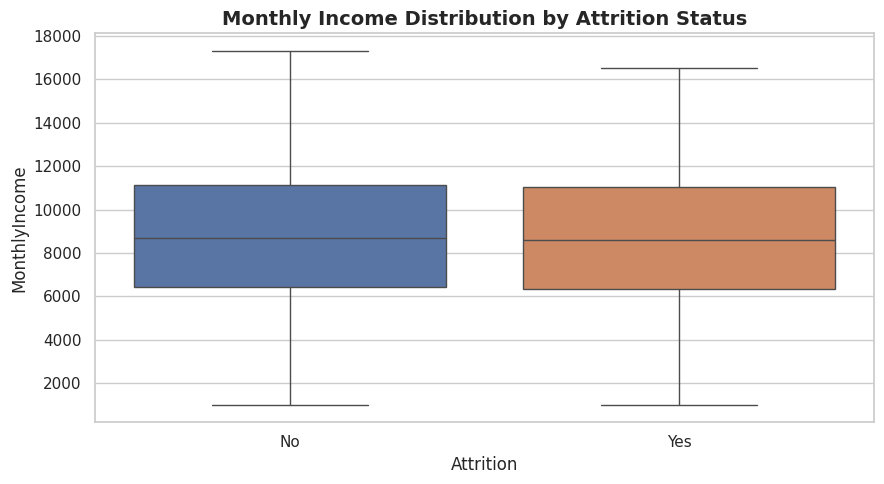

,mean,50%,min,max
Attrition,,,,
No,"8,809.92","8,671.00","1,009.00","17,309.00"
Yes,"8,625.67","8,616.00","1,009.00","16,537.00"


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=ax, palette=['#4C72B0','#DD8452'], hue='Attrition', legend=False)
ax.set_title('Monthly Income Distribution by Attrition Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/income_vs_attrition.png', dpi=120)
plt.show()

df.groupby('Attrition')['MonthlyIncome'].describe()[['mean','50%','min','max']]

## 8. Commute Distance & Business Travel

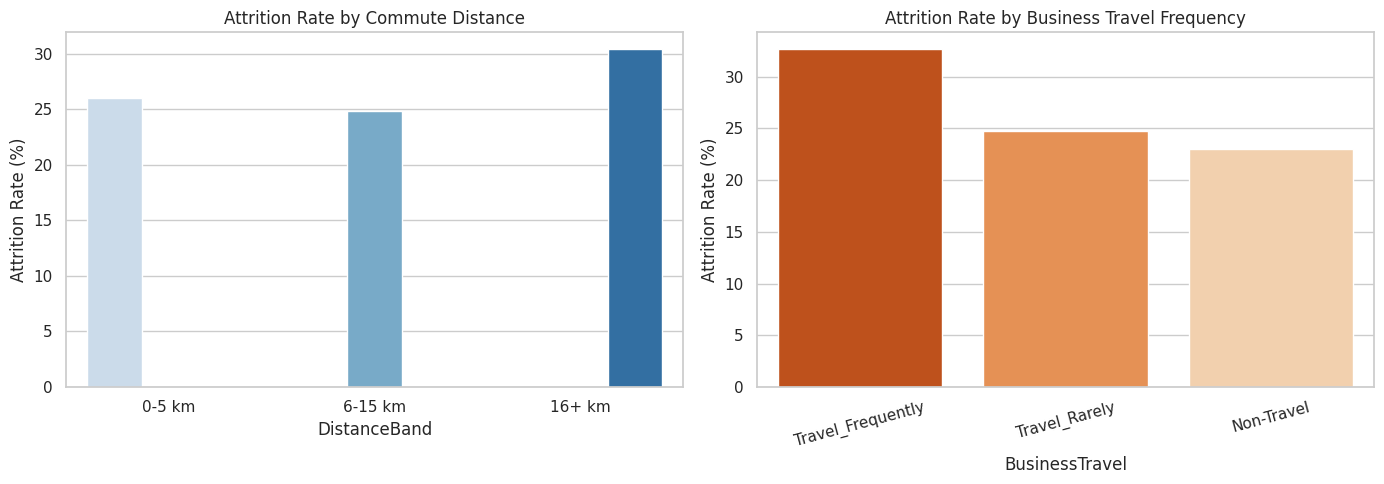

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['DistanceBand'] = pd.cut(df['DistanceFromHome'], bins=[0,5,15,30], labels=['0-5 km','6-15 km','16+ km'])
dist_attr = df.groupby('DistanceBand')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
sns.barplot(x=dist_attr.index, y=dist_attr.values, ax=axes[0], palette='Blues', hue=dist_attr.index, legend=False)
axes[0].set_title('Attrition Rate by Commute Distance')
axes[0].set_ylabel('Attrition Rate (%)')

travel_attr = df.groupby('BusinessTravel')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
sns.barplot(x=travel_attr.index, y=travel_attr.values, ax=axes[1], palette='Oranges_r', hue=travel_attr.index, legend=False)
axes[1].set_title('Attrition Rate by Business Travel Frequency')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../images/distance_travel.png', dpi=120)
plt.show()

## 9. Correlation Among Numeric Drivers

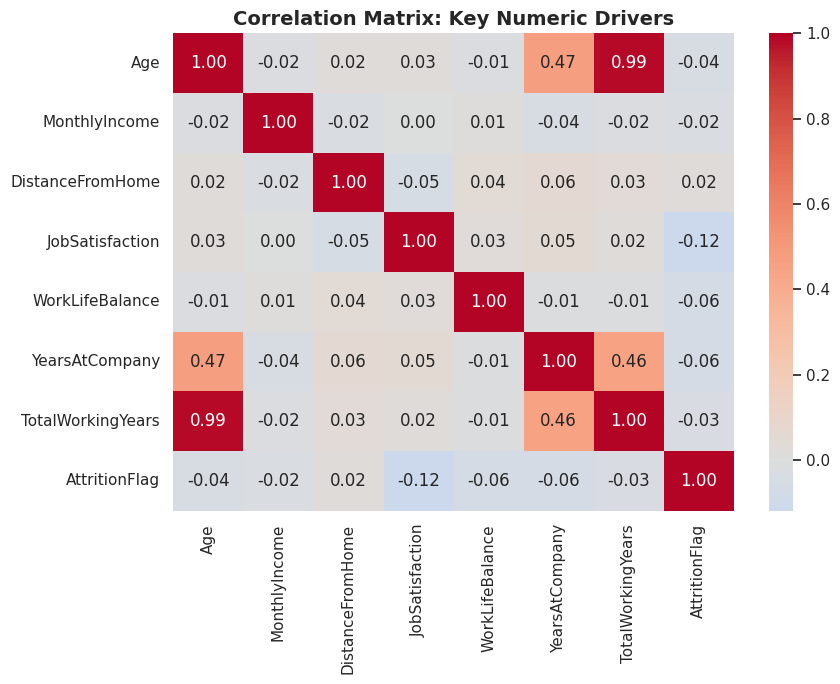

In [11]:
numeric_cols = ['Age','MonthlyIncome','DistanceFromHome','JobSatisfaction','WorkLifeBalance',
                'YearsAtCompany','TotalWorkingYears','AttritionFlag']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix: Key Numeric Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=120)
plt.show()

**Insight:** `AttritionFlag` correlates negatively (weakly) with `Age`, `MonthlyIncome`, `WorkLifeBalance`, and `YearsAtCompany` — consistent with the bar-chart findings above: younger, lower-paid, less-tenured employees with poorer work-life balance are more likely to leave. No single numeric factor is a dominant predictor on its own, which is why categorical drivers like OverTime show a clearer signal.

## 10. Key Takeaways for HR


- **OverTime is the single strongest attrition driver** — employees working overtime leave at
  nearly 2x the rate of those who don't (37.6% vs 22.1%).
- **First-year employees are the highest flight risk** (38.3% attrition in 0-1 yrs tenure),
  declining steadily with tenure — invest in first-year onboarding and engagement.
- **Low job satisfaction (36.1%) and poor work-life balance (32.2%)** are clear secondary
  drivers — both are addressable through management practices and workload policies.
- **Long commutes (16+ km) show elevated attrition (30.4%)** — relevant for remote/hybrid
  work policy decisions.
- **Department-level attrition is fairly uniform** (~20–27%) — this is not a department-specific
  problem; it's broadly distributed across the organization, which means interventions should
  target individual risk factors (overtime, tenure, satisfaction) rather than specific teams.

*Next steps: see `sql/` for the relational query layer behind these findings, and `powerbi/`
for the interactive HR dashboard built on this same cleaned dataset.*
